In [8]:
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, ggplot2, dplyr, lubridate, fixest)

# 1. HCRIS data (all the cleaning code)
final.hcris.v1996 <- read_csv('../data/output/HCRIS_Data_v1996.csv')
final.hcris.v2010 <- read_csv('../data/output/HCRIS_Data_v2010.csv')
# ... all the HCRIS cleaning ...
# ending with final.hcris.data

# 2. State crosswalk (must come BEFORE kff.final)
state.crosswalk <- tibble(
  state = c("AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
            "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
            "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
            "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
            "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY","DC"),
  State = c("Alabama","Alaska","Arizona","Arkansas","California","Colorado",
            "Connecticut","Delaware","Florida","Georgia","Hawaii","Idaho",
            "Illinois","Indiana","Iowa","Kansas","Kentucky","Louisiana",
            "Maine","Maryland","Massachusetts","Michigan","Minnesota",
            "Mississippi","Missouri","Montana","Nebraska","Nevada",
            "New Hampshire","New Jersey","New Mexico","New York",
            "North Carolina","North Dakota","Ohio","Oklahoma","Oregon",
            "Pennsylvania","Rhode Island","South Carolina","South Dakota",
            "Tennessee","Texas","Utah","Vermont","Virginia","Washington",
            "West Virginia","Wisconsin","Wyoming","District of Columbia")
)

# 3. KFF data (uses state.crosswalk, so must come AFTER it)
kff.dat <- read_csv('kff_data.csv', skip=2)
kff.final <- kff.dat %>%
  rename(State = Location,
         Expansion.Status = `Status of Medicaid Expansion Decision`,
         date_adopted = `Expansion Implementation Date`) %>%
  filter(State %in% state.crosswalk$State) %>%
  mutate(expanded = (Expansion.Status == "Adopted"),
         date_adopted = mdy(date_adopted)) %>%
  select(State, expanded, date_adopted)

# 4. Merge into final.data (must come last)
final.data <- final.hcris.data %>%
  left_join(state.crosswalk, by="state") %>%
  left_join(kff.final, by="State") %>%
  mutate(expand_year = year(date_adopted),
         expand = (year >= expand_year & !is.na(expand_year))) %>%
  rename(expand_ever = expanded)

Rows: 78508 Columns: 47
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (34): report, status, year, beds, tot_charges, net_pat_rev, tot_discount...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 57802 Columns: 48
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (12): provider_number, fy_start, fy_end, date_processed, date_created, d...
dbl (35): report, status, year, beds, tot_charges, tot_discounts, net_pat_re...
lgl  (1): npi

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:


In [13]:
# Question 1: Mean uncompensated care by year (in millions) --------------
q1.table <- final.data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(uncomp_care_constructed = tot_discounts + replace_na(bad_debt, 0)) %>%
  group_by(year) %>%
  summarize(mean_uncomp_care = mean(uncomp_care_constructed, na.rm=TRUE) / 1000000) %>%
  ungroup()

q1.table

year,mean_uncomp_care
<dbl>,<dbl>
2010,245.5817
2011,276.3442
2012,299.6402
2013,323.1160
2014,348.7476
2015,380.7853
2016,421.1792
2017,452.7537
2018,492.5119




Table: Mean Hospital Uncompensated Care by Year (2010-2018)

| Year| Mean Uncompensated Care (Millions)|
|----:|----------------------------------:|
| 2010|                             245.58|
| 2011|                             276.34|
| 2012|                             299.64|
| 2013|                             323.12|
| 2014|                             348.75|
| 2015|                             380.79|
| 2016|                             421.18|
| 2017|                             452.75|
| 2018|                             492.51|

`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


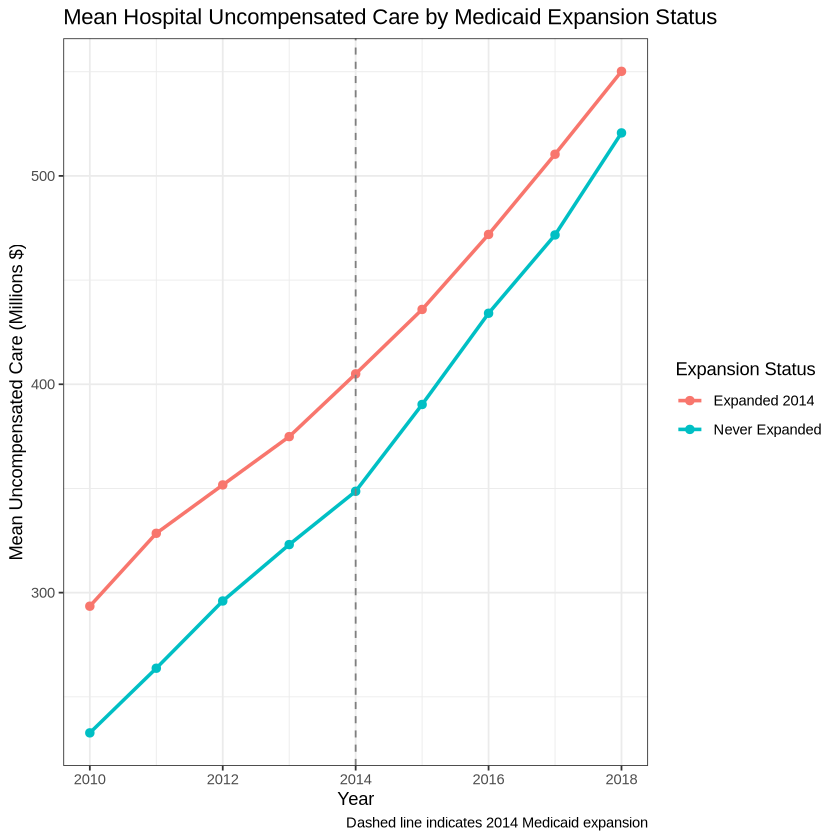

In [14]:
# Question 2: Plot mean uncompensated care by expansion status -----------
q2.data <- final.data %>%
  filter(year >= 2010, year <= 2018) %>%
  filter(expand_ever == FALSE | expand_year == 2014) %>%  # keep never-expanders and 2014 expanders only
  mutate(expand_group = ifelse(expand_ever == FALSE, "Never Expanded", "Expanded 2014")) %>%
  mutate(uncomp_care_constructed = tot_discounts + replace_na(bad_debt, 0)) %>%
  group_by(year, expand_group) %>%
  summarize(mean_uncomp_care = mean(uncomp_care_constructed, na.rm=TRUE) / 1000000) %>%
  ungroup()

ggplot(q2.data, aes(x=year, y=mean_uncomp_care, color=expand_group)) +
  geom_line(size=1) +
  geom_point(size=2) +
  geom_vline(xintercept=2014, linetype="dashed", color="grey50") +
  labs(title = "Mean Hospital Uncompensated Care by Medicaid Expansion Status",
       x = "Year",
       y = "Mean Uncompensated Care (Millions $)",
       color = "Expansion Status",
       caption = "Dashed line indicates 2014 Medicaid expansion") +
  theme_bw()

In [15]:
# Question 3: 2x2 DD table (2012 pre, 2015 post) -------------------------
q3.data <- final.data %>%
  filter(year %in% c(2012, 2015)) %>%
  filter(expand_ever == FALSE | expand_year == 2014) %>%
  mutate(uncomp_care_constructed = tot_discounts + replace_na(bad_debt, 0),
         post = (year == 2015),
         treat = (expand_ever == TRUE))  %>%
  group_by(post, treat) %>%
  summarize(mean_uncomp_care = mean(uncomp_care_constructed, na.rm=TRUE) / 1000000) %>%
  ungroup()

# Format as 2x2 table
q3.table <- q3.data %>%
  mutate(post = ifelse(post, "2015 (Post)", "2012 (Pre)"),
         treat = ifelse(treat, "Expanded 2014", "Never Expanded")) %>%
  pivot_wider(names_from = post, values_from = mean_uncomp_care) %>%
  rename(Group = treat) %>%
  mutate(Difference = `2015 (Post)` - `2012 (Pre)`)

# Add DD row
dd.row <- tibble(
  Group = "DD Estimate",
  `2012 (Pre)` = NA,
  `2015 (Post)` = NA,
  Difference = q3.table$Difference[q3.table$Group=="Expanded 2014"] - 
               q3.table$Difference[q3.table$Group=="Never Expanded"]
)

q3.table <- bind_rows(q3.table, dd.row)

knitr::kable(q3.table, 
             digits = 2,
             caption = "2x2 Difference-in-Differences Table of Mean Uncompensated Care (Millions $)")

`summarise()` has grouped output by 'post'. You can override using the
`.groups` argument.




Table: 2x2 Difference-in-Differences Table of Mean Uncompensated Care (Millions $)

|Group          | 2012 (Pre)| 2015 (Post)| Difference|
|:--------------|----------:|-----------:|----------:|
|Never Expanded |     295.99|      390.30|      94.31|
|Expanded 2014  |     351.70|      435.92|      84.22|
|DD Estimate    |         NA|          NA|     -10.09|

In [ ]:
#Q4
#Both groups saw uncompensated care rise over this period, likely due to general healthcare cost inflation and post-ACA coverage changes
#The expansion group rose less, consistent with Medicaid picking up previously uninsured patients
#Medicaid expansion would be expected to reduce uncompensated care because newly insured patients who previously couldn't pay now 
#have coverage, reducing the burden on hospitals.

In [16]:
# Question 5: Standard DD regression ------------------------------------
q5.data <- final.data %>%
  filter(year >= 2010, year <= 2018) %>%
  filter(expand_ever == FALSE | expand_year == 2014) %>%
  mutate(uncomp_care_constructed = (tot_discounts + replace_na(bad_debt, 0)) / 1000000)

q5.reg <- lm(uncomp_care_constructed ~ expand + year + expand_ever, 
             data = q5.data)

summary(q5.reg)


Call:
lm(formula = uncomp_care_constructed ~ expand + year + expand_ever, 
    data = q5.data)

Residuals:
    Min      1Q  Median      3Q     Max 
 -544.2  -369.1  -253.7    66.6 14050.1 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -69644.533   4031.842 -17.274  < 2e-16 ***
expandTRUE         -18.915     13.525  -1.399    0.162    
year                34.761      2.002  17.364  < 2e-16 ***
expand_everTRUE     59.550     10.862   5.482 4.23e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 752.2 on 38124 degrees of freedom
  (2144 observations deleted due to missingness)
Multiple R-squared:  0.01364,	Adjusted R-squared:  0.01356 
F-statistic: 175.7 on 3 and 38124 DF,  p-value: < 2.2e-16


In [17]:
# Question 6: DD with hospital and year fixed effects -------------------
q6.reg <- feols(uncomp_care_constructed ~ expand | provider_number + year,
                cluster = ~state,
                data = q5.data)

summary(q6.reg)

#Interpretation: The point estimate is similar (-18.9 vs -20.5) but the clustered standard errors in Q6 are much larger (34.4 vs 13.5), 
#which is the more reasonable estimate since hospitals within the same state aren't independent observations.

NOTE: 2,144 observations removed because of NA values (LHS: 2,144).



OLS estimation, Dep. Var.: uncomp_care_constructed
Observations: 38,128 
Fixed-effects: provider_number: 4,710,  year: 9
Standard-errors: Clustered (state) 
           Estimate Std. Error   t value Pr(>|t|) 
expandTRUE  -20.518    34.4102 -0.596277  0.55472 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 208.3     Adj. R2: 0.913661
              Within R2: 5.505e-4

In [18]:
# Question 7: DD with all states ----------------------------------------
q7.data <- final.data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(uncomp_care_constructed = (tot_discounts + replace_na(bad_debt, 0)) / 1000000)

q7.reg <- feols(uncomp_care_constructed ~ expand | provider_number + year,
                cluster = ~state,
                data = q7.data)

summary(q7.reg)

#Interpretation: Now the data is capturing the effect for states that expanded in 2015, 2016, 2017, and 2018. These late expanders may have 
#expanded under different conditions, and their "post" period is much shorter within the 2010-2018 window. This dilutes the estimated effect.

NOTE: 2,830 observations removed because of NA values (LHS: 2,830).



OLS estimation, Dep. Var.: uncomp_care_constructed
Observations: 51,907 
Fixed-effects: provider_number: 6,418,  year: 9
Standard-errors: Clustered (state) 
           Estimate Std. Error  t value Pr(>|t|) 
expandTRUE -2.59378    24.6838 -0.10508  0.91671 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
RMSE: 211.3     Adj. R2: 0.904794
              Within R2: 9.715e-6

NOTE: 2,144 observations removed because of NA values (LHS: 2,144).



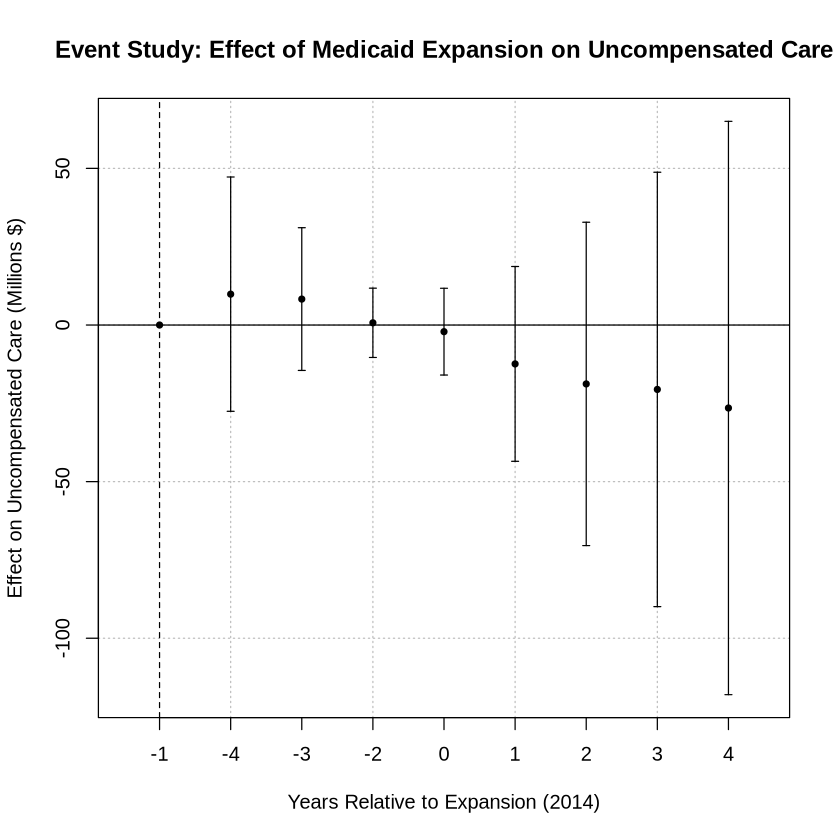

In [20]:
# Question 8: Event study - 2014 expanders and never-expanders only ------
q8.data <- q5.data %>%
  mutate(relative_year = ifelse(expand_ever == TRUE, year - 2014, -1),
         relative_year = factor(relative_year))

q8.reg <- feols(uncomp_care_constructed ~ i(relative_year, expand_ever, ref="-1") | 
                provider_number + year,
                cluster = ~state,
                data = q8.data)

iplot(q8.reg,
      main = "Event Study: Effect of Medicaid Expansion on Uncompensated Care",
      xlab = "Years Relative to Expansion (2014)",
      ylab = "Effect on Uncompensated Care (Millions $)")

NOTE: 3,346 observations removed because of NA values (LHS: 2,830, RHS: 569).



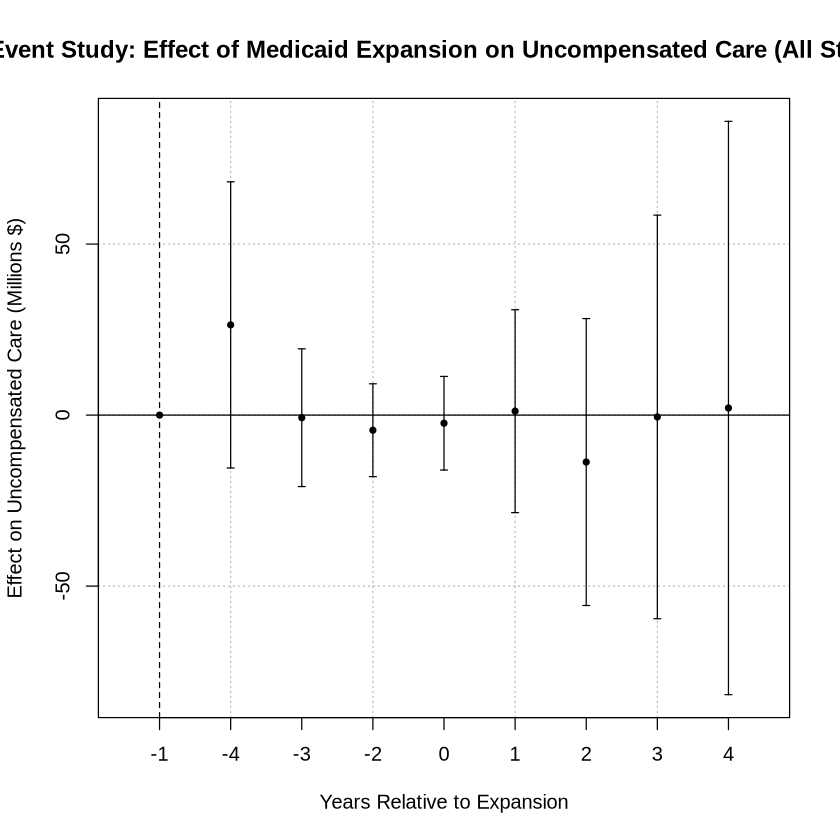

In [21]:
# Question 9: Event study - all states with binned event time ------------
q9.data <- final.data %>%
  filter(year >= 2010, year <= 2018) %>%
  mutate(uncomp_care_constructed = (tot_discounts + replace_na(bad_debt, 0)) / 1000000) %>%
  mutate(relative_year = ifelse(expand_ever == TRUE, year - expand_year, -1),
         relative_year = case_when(
           relative_year < -4 ~ -4,   # bin early pre-periods
           relative_year > 4  ~  4,   # bin late post-periods
           TRUE               ~ relative_year
         ),
         relative_year = factor(relative_year))

q9.reg <- feols(uncomp_care_constructed ~ i(relative_year, expand_ever, ref="-1") | 
                provider_number + year,
                cluster = ~state,
                data = q9.data)

iplot(q9.reg,
      main = "Event Study: Effect of Medicaid Expansion on Uncompensated Care (All States)",
      xlab = "Years Relative to Expansion",
      ylab = "Effect on Uncompensated Care (Millions $)")

In [ ]:
#Q10: Summary of Findings (Questions 5-9)
#Across all specifications, Medicaid expansion is associated with a reduction in hospital uncompensated care, though estimates vary 
#in magnitude and statistical significance. The baseline DD estimates in Q5 and Q6 suggest expansion reduced uncompensated care 
#by roughly $20 million per hospital, though neither estimate is statistically significant. Q8 provides moderate support for parallel trends 
#as the pre-period coefficients are small and close to zero, though not perfectly flat. This suggests the parallel trends assumption is 
#approximately satisfied for 2014 expanders versus never-expanders, but should be interpreted with some caution.
#Including late-expanding states in Q7 and Q9 substantially attenuates the estimated effect. One 
#limitation of the standard TWFE estimator in staggered designs is that it uses already-treated units as controls for not-yet-treated units, 
#creating "forbidden comparisons" that can bias estimates toward zero. This suggests the true effect of Medicaid expansion on uncompensated 
#care is better captured by the cleaner 2014-versus-never-expander comparisons in Q6 and Q8.